<a href="https://colab.research.google.com/github/RitalAlmutairi/Rital-ml-project/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**00 Importing libraries**

In [ ]:
# First, we import Pandas ,NumPy and matplotlib, which are the core libraries for data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading the dataset for Feature Engineering
insurance_processed=pd.read_csv("/content/sample_data/insurance_processed.csv")
print(insurance_processed.head())

   Unnamed: 0  age     sex     bmi  children smoker     region      charges
0           0   19  female  27.900         0    yes  southwest  16884.92400
1           1   18    male  33.770         1     no  southeast   1725.55230
2           2   28    male  33.000         3     no  southeast   4449.46200
3           3   33    male  22.705         0     no  northwest  21984.47061
4           4   32    male  28.880         0     no  northwest   3866.85520


**01   One-hot encode**

*   sex
*   smoker



In [ ]:
# The 'sex' and 'smoker' columns are categorical
insurance_processed= pd.get_dummies(insurance_processed, columns=["sex"], prefix="sex") # 'sex'

insurance_processed= pd.get_dummies(insurance_processed, columns=["smoker"], prefix="smoker") # 'smoker'

print(insurance_processed.head())

   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  
0     False      False        True  
1      True       True       False  
2      True       True       False  
3      True       True       False  
4      True       True       False  


**02   Ordinal encode**

*   'age'


In [ ]:
insurance_processed["age_category"]=pd.cut(insurance_processed["age"], bins=[0,18,60,109], labels=["Young", "Adult", "Senior"]) #  Split ages into groups
age_order = pd.CategoricalDtype(categories=["Young", "Adult", "Senior"], ordered=True)
insurance_processed["age_category"] = insurance_processed["age_category"].astype(age_order).cat.codes # Transfer labels to numbers

print(insurance_processed.head())

   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  age_category  
0     False      False        True             1  
1      True       True       False             0  
2      True       True       False             1  
3      True       True       False             1  
4      True       True       False             1  


**03   StandardScaler**

*   'bmi'
*   'charges'



In [ ]:
from sklearn.preprocessing import StandardScaler
insurance_processed[["bmi_std", "charges_std"]] = StandardScaler().fit_transform(insurance_processed[["bmi", "charges"]])
print(insurance_processed[["bmi_std", "charges_std"]].agg(["mean","std"]))

print(insurance_processed.head())

           bmi_std   charges_std
mean -2.285216e-16  3.587258e-17
std   1.000374e+00  1.000374e+00
   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  age_category   bmi_std  charges_std  
0     False      False        True             1 -0.453160     0.306234  
1      True       True       False             0  0.509422    -0.963703  
2      True       True       False             1  0.383155    -0.735515  
3      True       True       False             1 -1.305052     0.733435  
4      True       True       False             1 -0.292456    -0.784321  


**04   domain features**

*   'charges_age_ratio'
*   'High Risks'



In [ ]:
insurance_processed["charges_age_ratio"] = insurance_processed["charges"] / insurance_processed["age"]
insurance_processed["charges_age_ratio"] = insurance_processed["charges_age_ratio"].replace (0,insurance_processed["charges_age_ratio"].mean())

print(insurance_processed.head())

   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  age_category   bmi_std  charges_std  \
0     False      False        True             1 -0.453160     0.306234   
1      True       True       False             0  0.509422    -0.963703   
2      True       True       False             1  0.383155    -0.735515   
3      True       True       False             1 -1.305052     0.733435   
4      True       True       False             1 -0.292456    -0.784321   

   charges_age_ratio  
0         888.680211  
1          95.864017  
2         158.909357  


In [ ]:
insurance_processed["High Risks"] = (insurance_processed["age"] < 18) & (insurance_processed["smoker_yes"] == "True")

print(insurance_processed.head())


   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  age_category   bmi_std  charges_std  \
0     False      False        True             1 -0.453160     0.306234   
1      True       True       False             0  0.509422    -0.963703   
2      True       True       False             1  0.383155    -0.735515   
3      True       True       False             1 -1.305052     0.733435   
4      True       True       False             1 -0.292456    -0.784321   

   charges_age_ratio  High Risks  
0         888.680211       False  
1          95.864017  

**05    interaction feature**

In [ ]:
# Creating a new interaction term: age_bmi
insurance_processed["age_bmi"] = insurance_processed["age"] * insurance_processed["bmi"]

print(insurance_processed.head())

   Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0           0   19  27.900         0  southwest  16884.92400        True   
1           1   18  33.770         1  southeast   1725.55230       False   
2           2   28  33.000         3  southeast   4449.46200       False   
3           3   33  22.705         0  northwest  21984.47061       False   
4           4   32  28.880         0  northwest   3866.85520       False   

   sex_male  smoker_no  smoker_yes  age_category   bmi_std  charges_std  \
0     False      False        True             1 -0.453160     0.306234   
1      True       True       False             0  0.509422    -0.963703   
2      True       True       False             1  0.383155    -0.735515   
3      True       True       False             1 -1.305052     0.733435   
4      True       True       False             1 -0.292456    -0.784321   

   charges_age_ratio  High Risks  age_bmi  
0         888.680211       False  530.100  
1   

**06    Log-transform**

*   histogram of  'charges'  before and after
*   Log1p Transformation



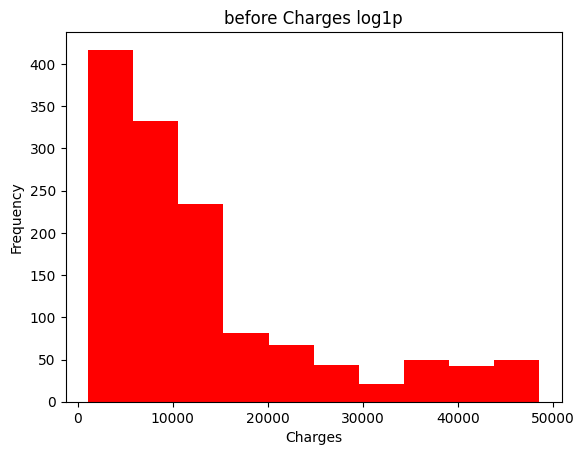

In [ ]:
plt.hist(insurance_processed["charges"],color="red")
plt.title("before Charges log1p")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

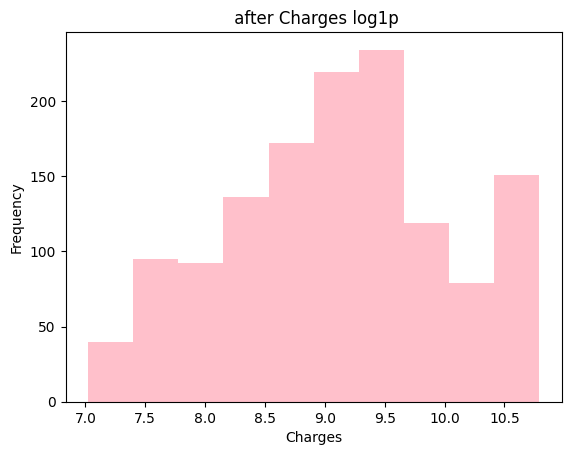

In [ ]:
# Fix skewed data using Log Transformation
insurance_processed["charges_log1p"] = np.log1p(insurance_processed["charges"])
plt.hist(insurance_processed["charges_log1p"],color="pink")
plt.title(" after Charges log1p")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()


**07   redundant features**

In [ ]:
corr_matrix = insurance_processed.corr(numeric_only=True).abs()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle = corr_matrix.where(mask)
to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
insurance_processed = insurance_processed.drop(columns=to_drop)

print("\nColumns removed:\n", to_drop)


Columns removed:
 ['sex_male', 'smoker_yes', 'bmi_std', 'charges_std']


In [ ]:
insurance_features = insurance_processed.copy()
insurance_features.to_csv("insurance_features.csv")
print(insurance_features)

      Unnamed: 0  age     bmi  children     region      charges  sex_female  \
0              0   19  27.900         0  southwest  16884.92400        True   
1              1   18  33.770         1  southeast   1725.55230       False   
2              2   28  33.000         3  southeast   4449.46200       False   
3              3   33  22.705         0  northwest  21984.47061       False   
4              4   32  28.880         0  northwest   3866.85520       False   
...          ...  ...     ...       ...        ...          ...         ...   
1332        1333   50  30.970         3  northwest  10600.54830       False   
1333        1334   18  31.920         0  northeast   2205.98080        True   
1334        1335   18  36.850         0  southeast   1629.83350        True   
1335        1336   21  25.800         0  southwest   2007.94500        True   
1336        1337   61  29.070         0  northwest  29141.36030        True   

      smoker_no  age_category  charges_age_ratio  H